# Two-Stage Lang2Vec Clustering For High-Resource Languages

This notebook mirrors the clustering setup in `data_prep/lang_cluster_analysis/comprehensive_language_analysis_lang2vec.ipynb` but limits the analysis to the 200 languages with the highest number of documents in `fineweb2-language-distribution.csv`. After intersecting with Lang2Vec coverage we perform a silhouette sweep to pick the optimal number of clusters (genetic distances, average linkage), then visualize the resulting groups and inspect which clusters are farthest apart.


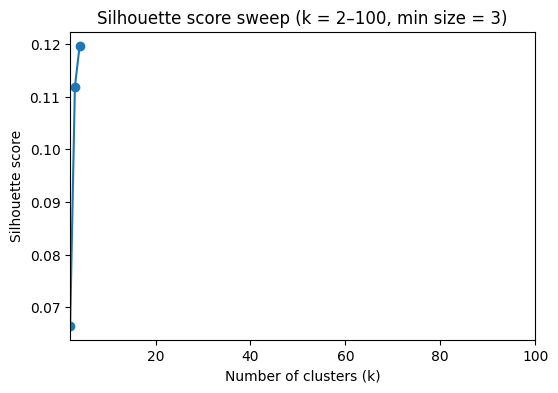

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


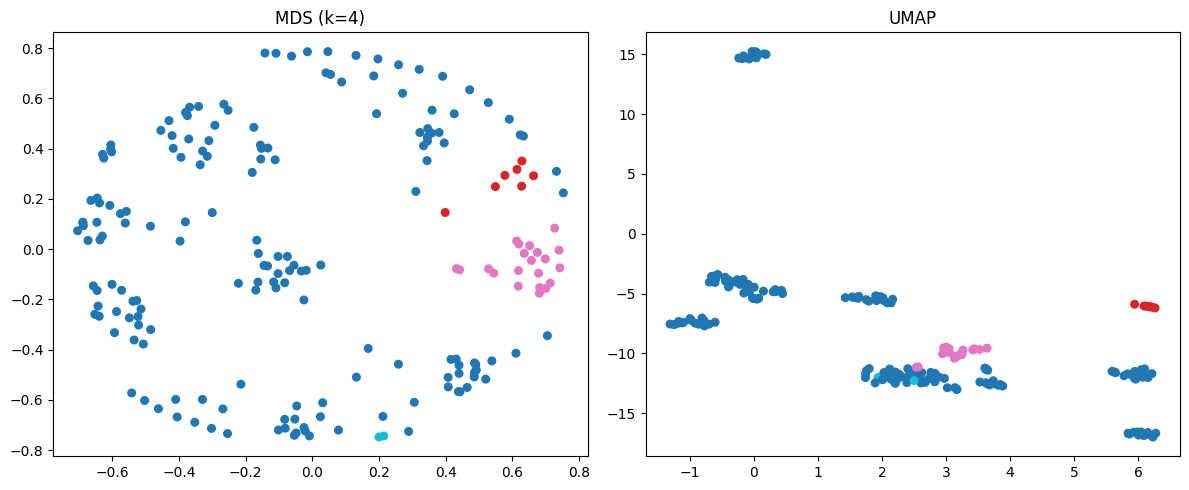

4 farthest clusters: [np.int64(0), np.int64(1), np.int64(2)]


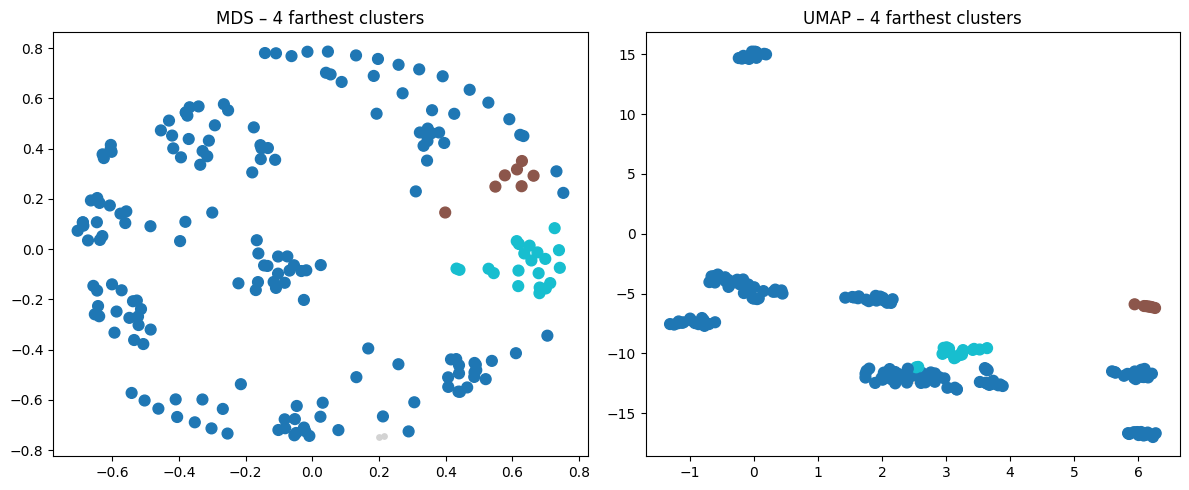

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.manifold import MDS
from cluster_lang2vec_distances import auto_k, build_distance_matrix, cluster_with_k
from lang2vec import lang2vec as l2v
import umap.umap_ as umap

# Load + filter
df = pd.read_csv("/home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/base_data/fineweb2-language-distribution.csv")
df = df[df.split == "train"]

top = (
    df.assign(documents=pd.to_numeric(df.documents, errors="coerce").fillna(0))
      .groupby(["code", "name", "family", "resource_availability"], as_index=False)
      ["documents"].sum()
      .sort_values("documents", ascending=False)
      .head(200)
)
langs = top[top.code.isin(l2v.DISTANCE_LANGUAGES)].reset_index(drop=True)
codes = langs.code.tolist()

matrix = build_distance_matrix(codes, "genetic")

# --- Silhouette sweep (keep original plot) ---
best_k, scores = auto_k(matrix, 2, 100, "average", min_cluster_size=1)
ks, vals = zip(*scores)

plt.figure(figsize=(6, 4))
plt.plot(ks, vals, marker="o")
plt.xlim(2, 100)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score sweep (k = 2–100, min size = 3)")
plt.show()

# cluster + mds plot + umap plot
labels = cluster_with_k(matrix, best_k, "average")
coords_mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0).fit_transform(matrix)
coords_umap = umap.UMAP(metric="precomputed", random_state=0).fit_transform(matrix)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c=labels, cmap="tab10", s=30)
ax[0].set_title(f"MDS (k={best_k})")

ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c=labels, cmap="tab10", s=30)
ax[1].set_title("UMAP")

plt.tight_layout()
plt.show()

# --- 4 farthest clusters with min size = 3 ---
clusters = {c: np.where(labels == c)[0] for c in set(labels)}
clusters = {c: idx for c, idx in clusters.items() if len(idx) >= 3}

pairs = [
    (a, b, matrix[np.ix_(ia, ib)].mean())
    for a, ia in clusters.items()
    for b, ib in clusters.items()
    if b > a
]

top_clusters = []
for a, b, _ in sorted(pairs, key=lambda x: x[2], reverse=True):
    for c in (a, b):
        if c not in top_clusters:
            top_clusters.append(c)
        if len(top_clusters) == 4:
            break
    if len(top_clusters) == 4:
        break

print("4 farthest clusters:", top_clusters)

# --- Highlight 4 farthest clusters: MDS + UMAP ---
mask = np.isin(labels, top_clusters)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
ax[0].scatter(coords_mds[mask, 0], coords_mds[mask, 1],
              c=labels[mask], cmap="tab10", s=60)
ax[0].set_title("MDS – 4 farthest clusters")

ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)
ax[1].scatter(coords_umap[mask, 0], coords_umap[mask, 1],
              c=labels[mask], cmap="tab10", s=60)
ax[1].set_title("UMAP – 4 farthest clusters")

plt.tight_layout()
plt.show()



Selected 12 languages: [154  28 152  18 144 198  86 106 102]


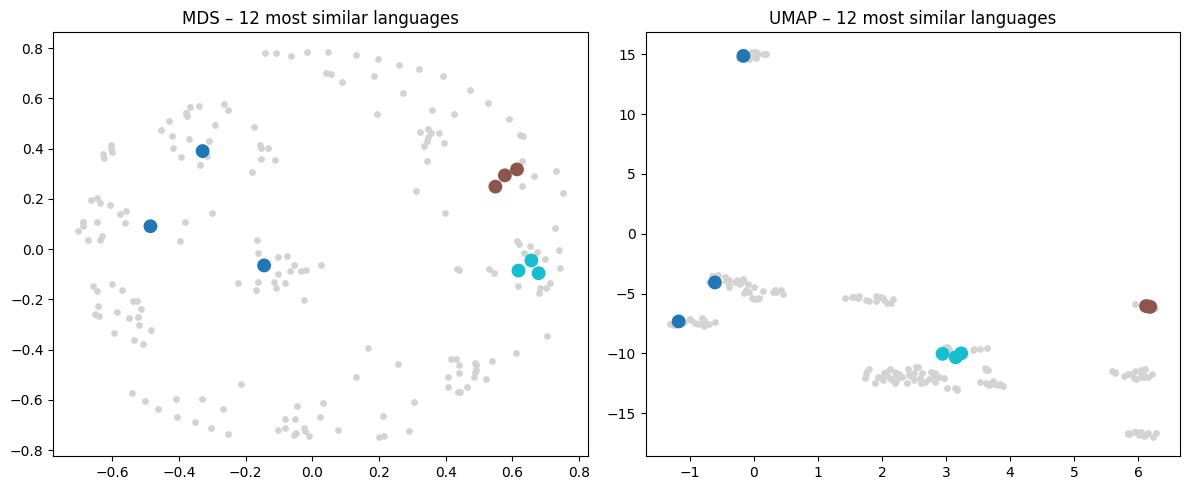

code resource_availability           subset
 hun                  HIGH         hun_Latn
 hun                  HIGH hun_Latn_removed
 ilo                   LOW         ilo_Latn
 ilo                   LOW ilo_Latn_removed
 jav                   LOW         jav_Latn
 jav                   LOW jav_Latn_removed
 krl                   LOW         krl_Latn
 krl                   LOW krl_Latn_removed
 lit                MEDIUM lit_Latn_removed
 lit                MEDIUM         lit_Latn
 san                   LOW         san_Deva
 san                   LOW san_Deva_removed
 san                   LOW         san_Latn
 san                   LOW san_Latn_removed
 sun                   LOW         sun_Latn
 sun                   LOW sun_Latn_removed
 vep                   LOW         vep_Latn
 vep                   LOW vep_Latn_removed
 wln                   LOW         wln_Latn
 wln                   LOW wln_Latn_removed


In [69]:
# now we continue searching the 3 most similar languages within each of the 4 clusters

from itertools import combinations

selected = {}

for c in top_clusters:
    idx = np.where(labels == c)[0]
    D = matrix[np.ix_(idx, idx)]

    # mean distance of each language to others in same cluster
    mean_d = D.mean(axis=1)
    top3 = idx[np.argsort(mean_d)[:3]]
    selected[c] = top3

final_langs = np.concatenate(list(selected.values()))
print("Selected 12 languages:", final_langs)


mask = np.isin(np.arange(len(labels)), final_langs)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
ax[0].scatter(coords_mds[mask, 0], coords_mds[mask, 1],
              c=labels[mask], cmap="tab10", s=80)
ax[0].set_title("MDS – 12 most similar languages")

ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)
ax[1].scatter(coords_umap[mask, 0], coords_umap[mask, 1],
              c=labels[mask], cmap="tab10", s=80)
ax[1].set_title("UMAP – 12 most similar languages")

plt.tight_layout()
plt.show()


selected_codes = [codes[i] for i in final_langs]

# lookup in original CSV
info = (
    df.loc[df.code.isin(selected_codes),
           ["code", "resource_availability", "subset"]]
      .drop_duplicates()
      .sort_values("code")
)

print(info.to_string(index=False))

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


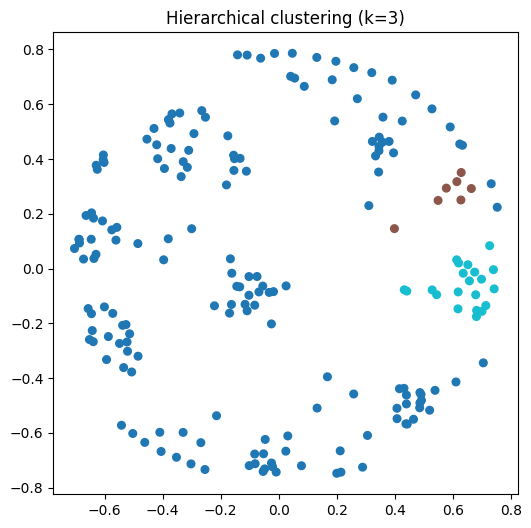

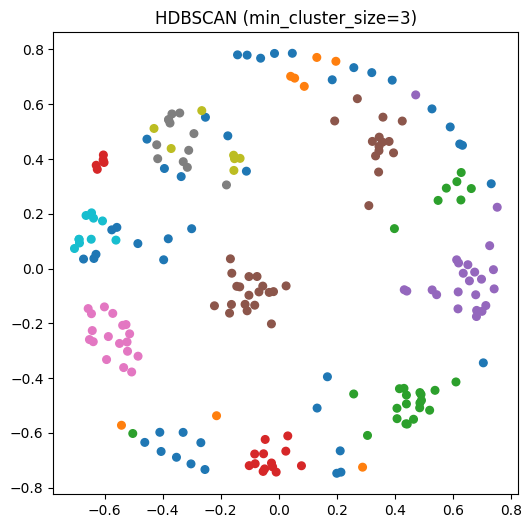

HDBSCAN clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)}
HDBSCAN noise points: 39


In [70]:
import hdbscan
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import numpy as np

# --- HDBSCAN clustering (distance matrix) ---
hdb = hdbscan.HDBSCAN(
    metric="precomputed",
    min_cluster_size=3,
    min_samples=3
)
hdb_labels = hdb.fit_predict(matrix)   # -1 = noise

# --- Shared MDS embedding ---
coords = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=0
).fit_transform(matrix)

# --- Plot 1: Hierarchical clustering (baseline) ---
plt.figure(figsize=(6, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=30)
plt.title(f"Hierarchical clustering (k={best_k})")
plt.show()

# --- Plot 2: HDBSCAN result ---
plt.figure(figsize=(6, 6))
plt.scatter(
    coords[:, 0], coords[:, 1],
    c=hdb_labels,
    cmap="tab10",
    s=30
)
plt.title("HDBSCAN (min_cluster_size=3)")
plt.show()

# --- Diagnostics ---
print("HDBSCAN clusters:", set(hdb_labels) - {-1})
print("HDBSCAN noise points:", np.sum(hdb_labels == -1))
